In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\HP\Desktop\ip2\superstore_final_dataset (1).csv",
    encoding="latin1"
)

print(df.shape)
print(df.columns.tolist())

(9800, 18)
['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


In [5]:
# Convert date columns
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing postal codes
df['Postal_Code'] = df['Postal_Code'].fillna(0)

# Create time-based columns
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()

# Revenue column
df['Revenue'] = df['Sales']

print("Shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())

Shape: (9800, 22)
Total missing values: 0


In [6]:
# Calculate KPIs

total_revenue = df['Revenue'].sum()
total_orders = df['Order_ID'].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 2261536.78
Total Orders: 4922
Average Order Value: 459.48


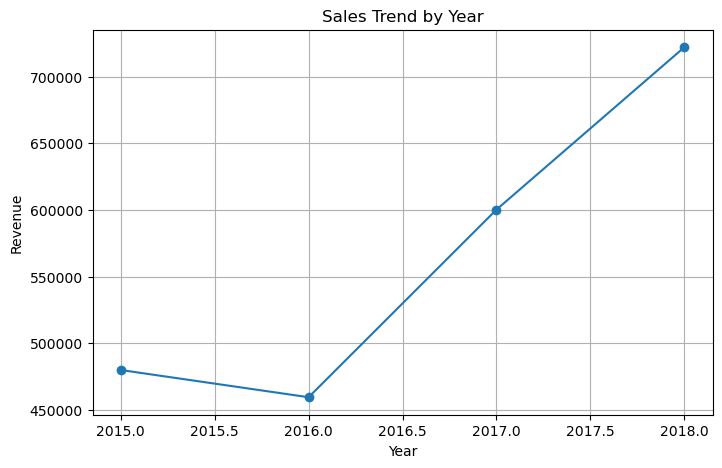

In [7]:
import matplotlib.pyplot as plt

yearly_sales = df.groupby('Year')['Revenue'].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='line', marker='o')
plt.title('Sales Trend by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Revenue, dtype: float64


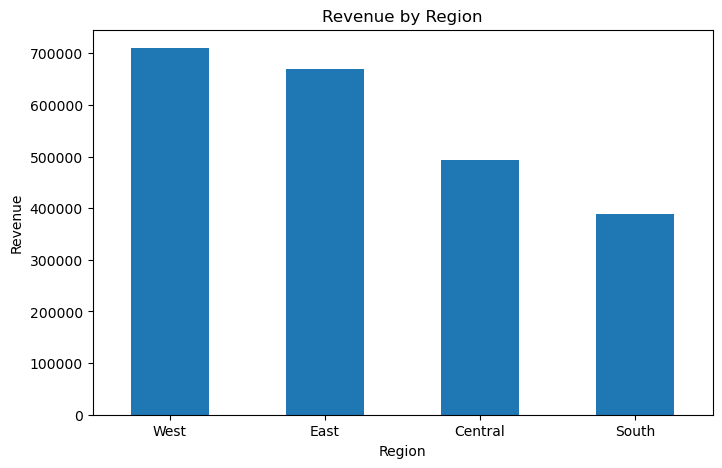

In [8]:
import matplotlib.pyplot as plt

regional_sales = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

print(regional_sales)

plt.figure(figsize=(8,5))
regional_sales.plot(kind='bar')
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Revenue, dtype: float64


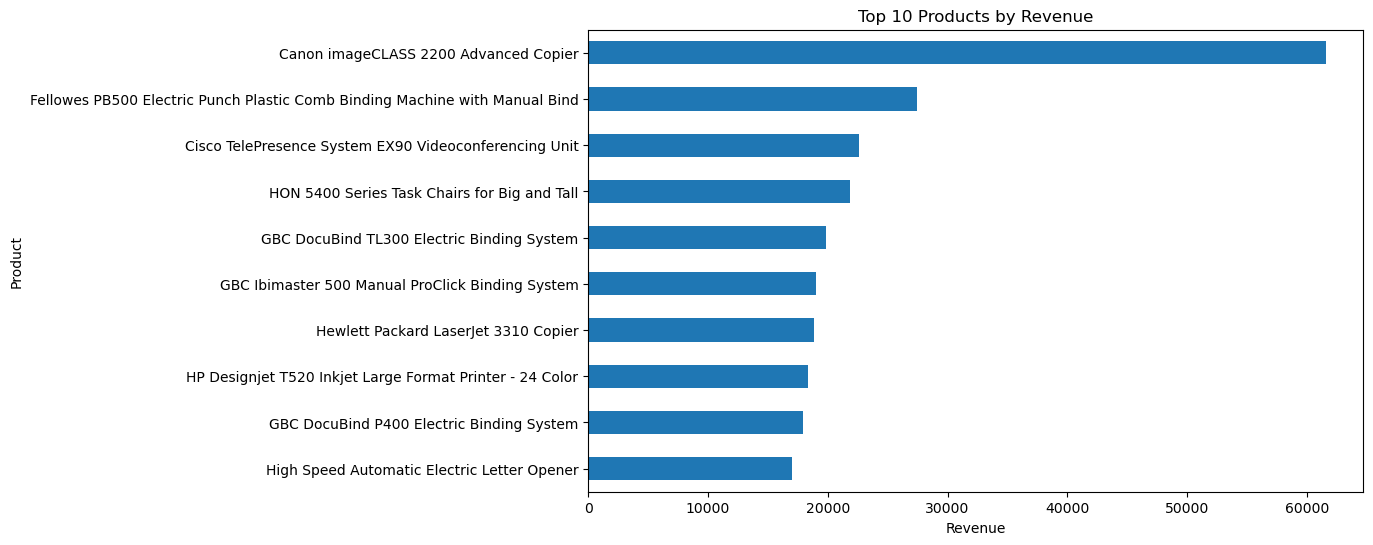

In [9]:
top_products = (
    df.groupby('Product_Name')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Revenue, dtype: float64


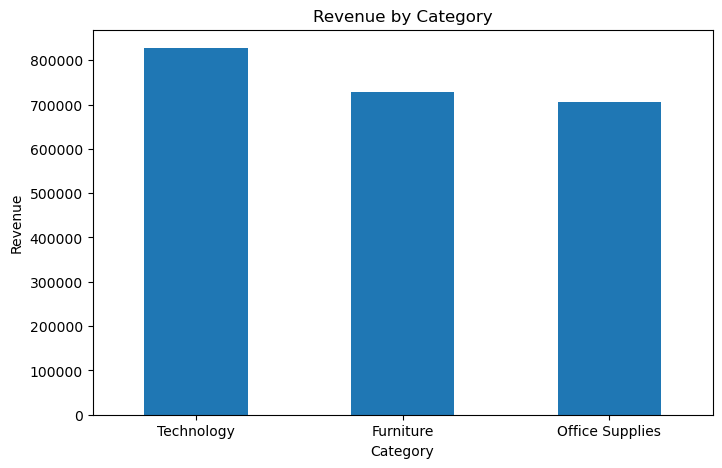

In [10]:
category_sales = (
    df.groupby('Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

Sub_Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Revenue, dtype: float64


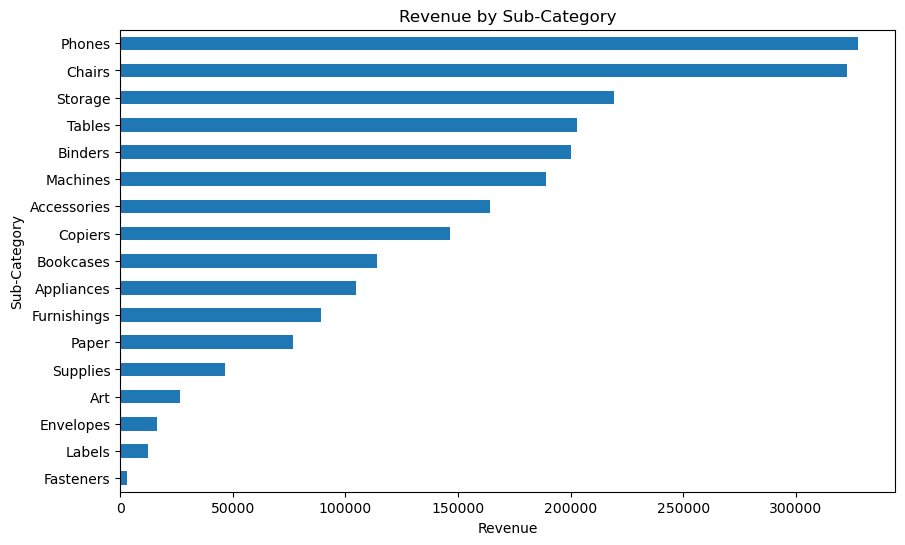

In [11]:
subcategory_sales = (
    df.groupby('Sub_Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(subcategory_sales)

plt.figure(figsize=(10,6))
subcategory_sales.sort_values().plot(kind='barh')
plt.title('Revenue by Sub-Category')
plt.xlabel('Revenue')
plt.ylabel('Sub-Category')
plt.show()

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Revenue, dtype: float64


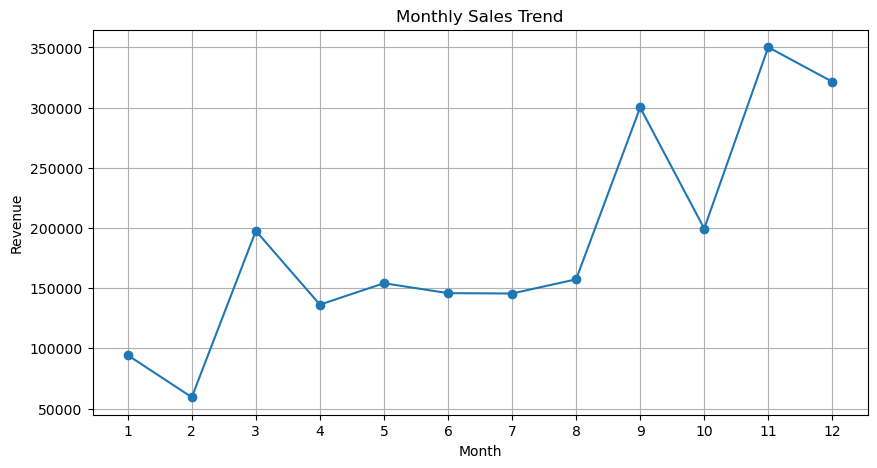

In [12]:
monthly_sales = (
    df.groupby('Month')['Revenue']
    .sum()
)

print(monthly_sales)

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()